In [ ]:
# Deep Learning Regression: Architecture Comparison (TensorFlow)

# Phase 1: Data Loading & Exploratory Data Analysis
# In this section, we load the California Housing dataset, inspect feature distributions, 
# and analyze correlations to understand the underlying data structure before modeling.

In [36]:
# --- 1. Import Core Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# ML and Deep Learning Libraries
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras import Input
from tensorflow.keras.layers import LeakyReLU, Activation, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# --- 2. Load Dataset ---
california = fetch_california_housing(as_frame=True)
df = california.frame  # pandas DataFrame

In [2]:
# --- 3. Initial Inspection ---
print("Форма даних:", df.shape)
print("Назви ознак:", df.columns.tolist())
display(df.head())
display(df.describe())
print("Кількість пропусків у стовпцях:")
print(df.isnull().sum())

Форма даних: (20640, 9)
Назви ознак: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


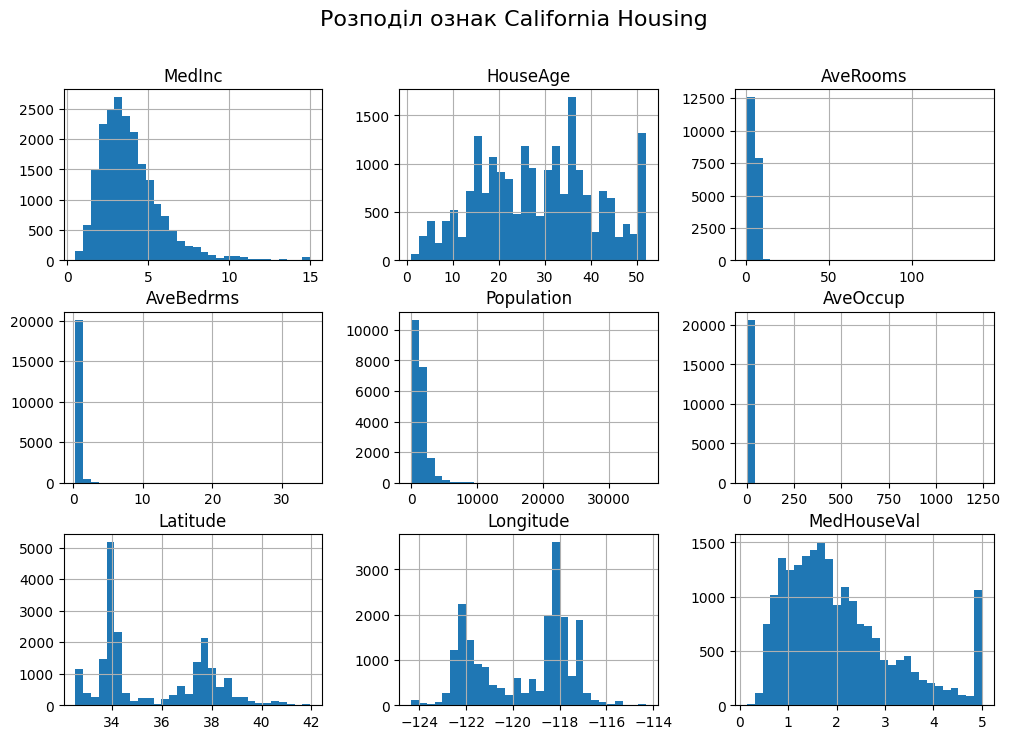

In [4]:
# --- 4. Feature Distributions ---
df.hist(figsize=(12, 8), bins=30)
plt.suptitle("Розподіл ознак California Housing", fontsize=16)
plt.show()

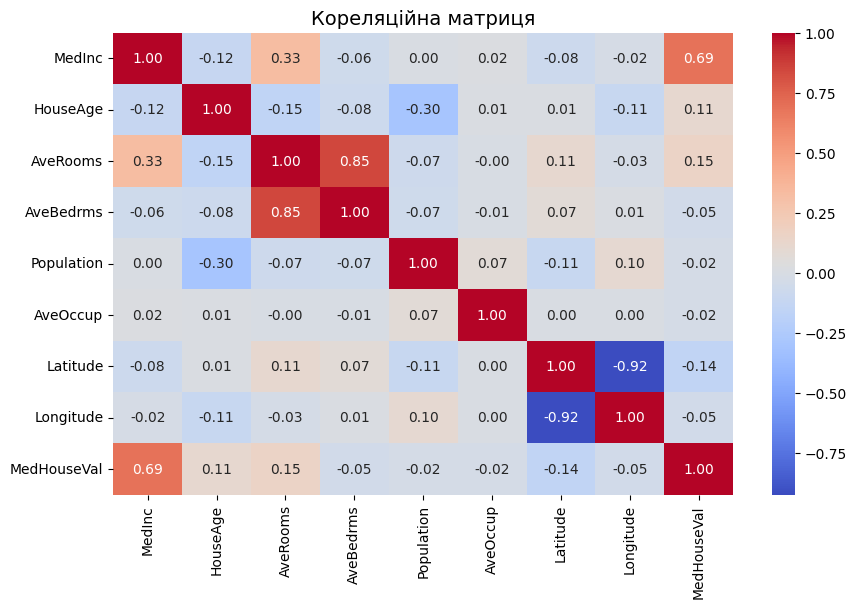

In [5]:
# --- 5. Correlation Matrix ---
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Кореляційна матриця", fontsize=14)
plt.show()

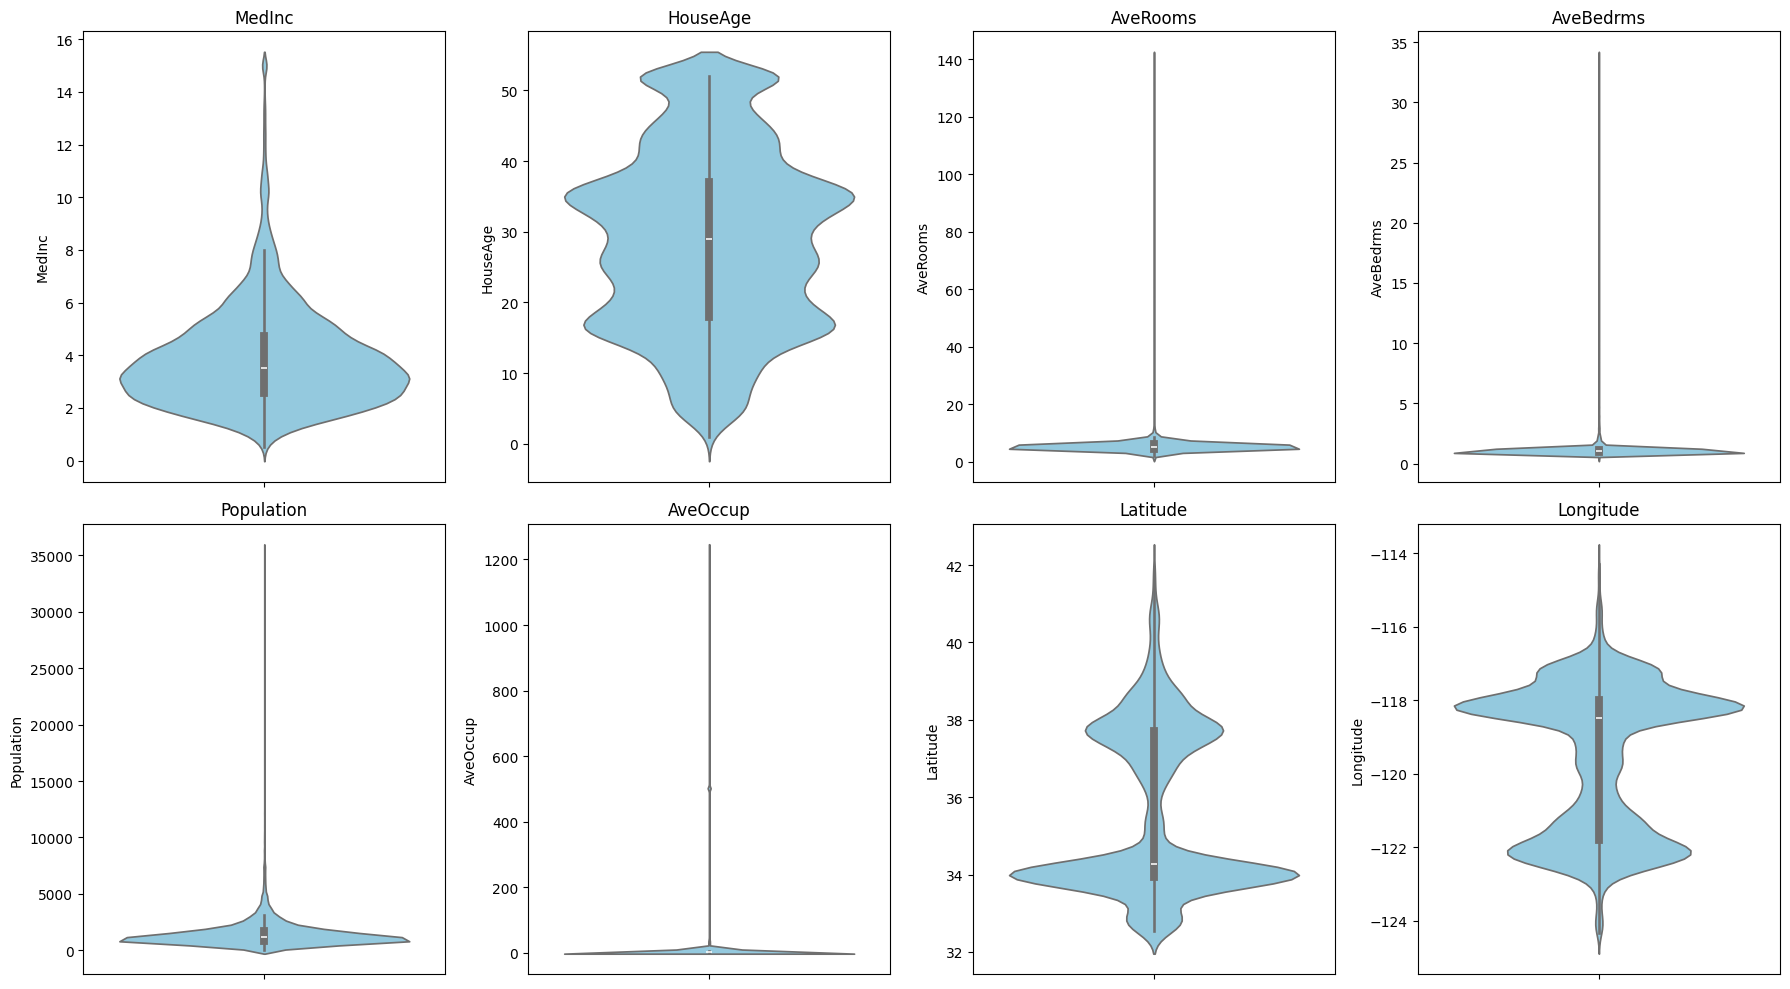

In [14]:
# --- 6. Violin Plots for Feature Spread ---
features = df.columns.drop("MedHouseVal")

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten() 

for ax, col in zip(axes, features):
    sns.violinplot(y=df[col], ax=ax, inner="box", color="skyblue")
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
# Phase 2: Preprocessing & Principal Component Analysis (PCA)
# We split the data into Train (70%), Validation (15%), and Test (15%) sets. After standardizing the features, we apply PCA to reduce 
# dimensionality to 5 components while attempting to retain maximum variance.

In [16]:
# Define Features (X) and Target (y)
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# Train (70%), Validation (15%), Test (15%) Split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (14448, 8) (14448,)
Val: (3096, 8) (3096,)
Test: (3096, 8) (3096,)


In [17]:
# --- Feature Scaling ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Explained variance ratio (5 components): [0.25332065 0.23393326 0.15935984 0.12964566 0.12550435]
Total variance explained: 0.901763752448135


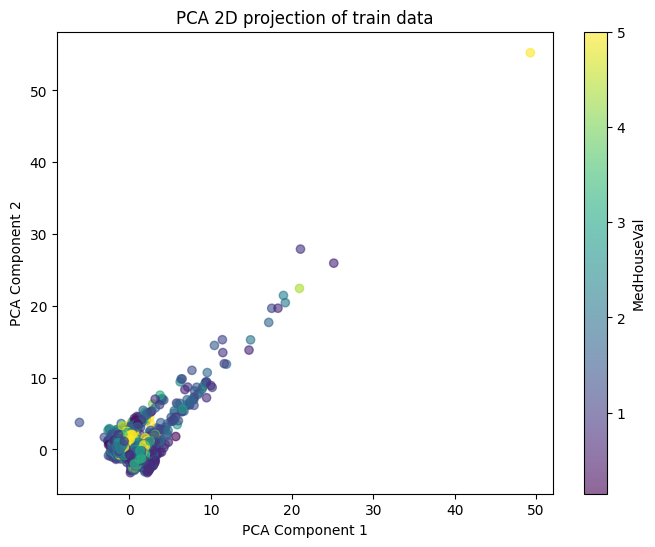

In [19]:
# --- Dimensionality Reduction (PCA) ---
pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

print("Explained variance ratio (5 components):", pca.explained_variance_ratio_)
print("Total variance explained:", sum(pca.explained_variance_ratio_))

# Visualize PCA Projection
plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap='viridis', alpha=0.6)
plt.colorbar(label='MedHouseVal')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA 2D projection of train data')
plt.show()


In [ ]:
# Phase 3: Neural Network Architectures Definition
# We define multiple architectures to analyze the impact of complexity and activation functions:
# 1. **Basic Models:** Feedforward networks using ReLU and LeakyReLU.
# 2. **Advanced Models:** Deep networks implementing Dropout, Batch Normalization, L2 Regularization, comparing ReLU and GELU activations.

In [27]:
# --- 1. Basic Model ---
model_basic = Sequential([
    Input(shape=(input_dim,)),  
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

# --- 2. Advanced model ---
model_advanced = Sequential([
    Input(shape=(input_dim,)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(1)
])

models = {
    "Базова мережа": model_basic,
    "Ускладнена мережа": model_advanced
}

for name, model in models.items():
    print(f"\n{name}:\n")
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    model.summary()



Базова мережа:



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                     │ (None, 64)                  │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

...

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                     │ (None, 128)                 │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,905 (46.50 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [30]:
input_dim = X_train_pca.shape[1]
epochs = 15
batch_size = 32

# --- 1. Basic Model (ReLU) ---
model_basic_relu = Sequential([
    Input(shape=(input_dim,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])
model_basic_relu.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# --- 2. Basic Model (LeakyReLU) ---
model_basic_leaky = Sequential([
    Input(shape=(input_dim,)),
    Dense(64),
    LeakyReLU(alpha=0.1),
    Dense(32),
    LeakyReLU(alpha=0.1),
    Dense(1)
])
model_basic_leaky.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# --- 3. Advanced Model (ReLU + Regularization) ---
model_adv_relu = Sequential([
    Input(shape=(input_dim,)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(1)
])
model_adv_relu.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# --- 4. Advanced Model (GELU + Regularization) ---
model_adv_gelu = Sequential([
    Input(shape=(input_dim,)),
    Dense(128, kernel_regularizer=l2(0.001)),
    Activation("gelu"),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, kernel_regularizer=l2(0.001)),
    Activation("gelu"),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, kernel_regularizer=l2(0.001)),
    Activation("gelu"),
    Dense(1)
])
model_adv_gelu.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])


# Model training
histories = {}

histories['basic_relu'] = model_basic_relu.fit(
    X_train_pca, y_train,
    validation_data=(X_val_pca, y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

histories['basic_leaky'] = model_basic_leaky.fit(
    X_train_pca, y_train,
    validation_data=(X_val_pca, y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

histories['adv_relu'] = model_adv_relu.fit(
    X_train_pca, y_train,
    validation_data=(X_val_pca, y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

histories['adv_gelu'] = model_adv_gelu.fit(
    X_train_pca, y_train,
    validation_data=(X_val_pca, y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)


C:\Python312\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.1491 - mae: 0.7477 - val_loss: 0.6873 - val_mae: 0.6044
Epoch 2/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6528 - mae: 0.5965 - val_loss: 0.6414 - val_mae: 0.5935
Epoch 3/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6281 - mae: 0.5809 - val_loss: 0.6235 - val_mae: 0.5823
Epoch 4/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6083 - mae: 0.5733 - val_loss: 0.6156 - val_mae: 0.5662
Epoch 5/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5938 - mae: 0.5644 - val_loss: 0.6021 - val_mae: 0.5493
Epoch 6/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6053 - mae: 0.5603 - val_loss: 0.6156 - val_mae: 0.5540
Epoch 7/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5738 - mae: 0.5523 - val_loss: 0.5886 - val_mae: 0.5516
Epoch 8/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5672 - mae: 0.5476 - val_loss: 0.5775 - val_mae: 0.5565
Epoch 9/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - lo

In [ ]:
# Phase 5: Evaluation & Learning Curves Analysis
# We evaluate the final performance of all models across Train, Validation, and Test datasets using MSE, RMSE, MAE, and R² Score metrics. 
# We also plot learning curves to analyze model convergence and check for overfitting.

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 894us/step
Базова ReLU: MAE=0.5360, MSE=0.5445, RMSE=0.7379
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Базова LeakyReLU: MAE=0.5315, MSE=0.5495, RMSE=0.7413
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Ускладнена ReLU: MAE=0.5364, MSE=0.5768, RMSE=0.7595
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Ускладнена GELU: MAE=0.5494, MSE=0.5923, RMSE=0.7696


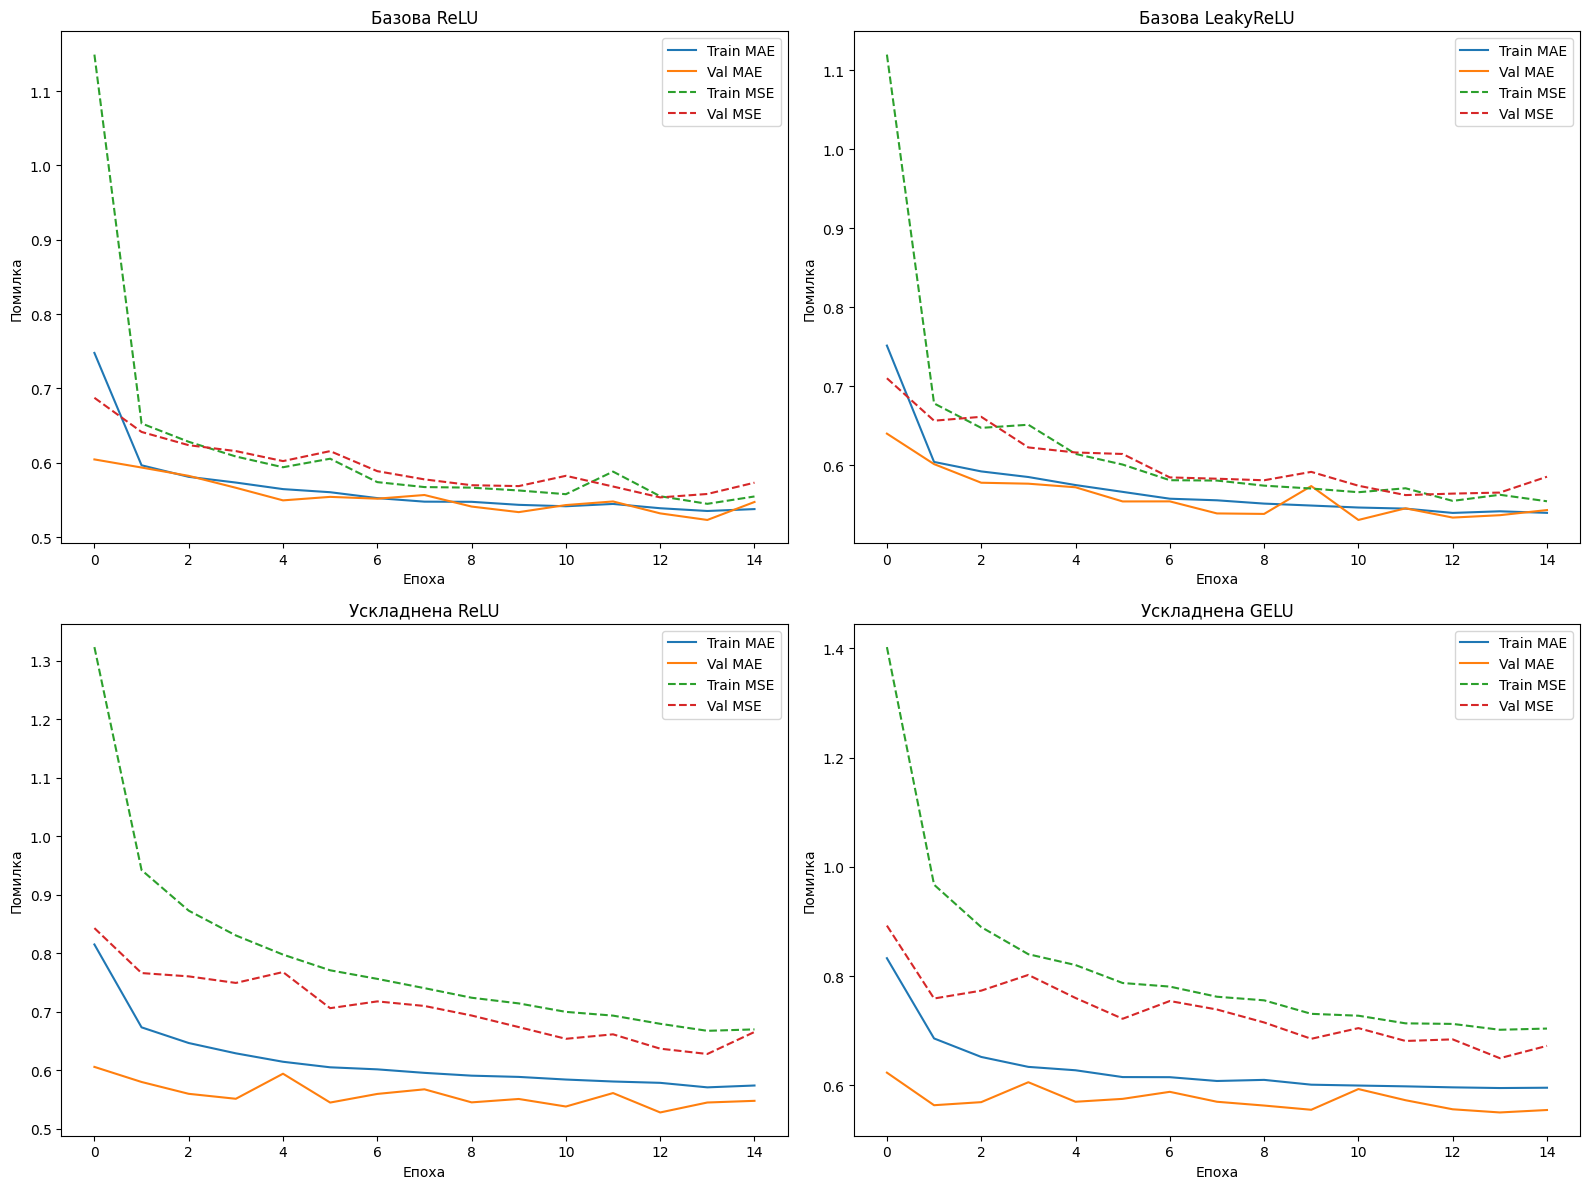

In [32]:
# Function to calculate RMSE
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

# List of learning models and histories
models = {
    "Базова ReLU": (model_basic_relu, histories['basic_relu']),
    "Базова LeakyReLU": (model_basic_leaky, histories['basic_leaky']),
    "Ускладнена ReLU": (model_adv_relu, histories['adv_relu']),
    "Ускладнена GELU": (model_adv_gelu, histories['adv_gelu'])
}

# test evaluation
for name, (model, history) in models.items():
    y_pred = model.predict(X_test_pca).ravel()  # transform (n_samples,1) -> (n_samples,)
    mae_val = np.mean(np.abs(y_test - y_pred))
    mse_val = np.mean((y_test - y_pred)**2)
    rmse_val = np.sqrt(mse_val)
    print(f"{name}: MAE={mae_val:.4f}, MSE={mse_val:.4f}, RMSE={rmse_val:.4f}")

# Building learning curves
plt.figure(figsize=(16, 12))

for i, (name, (model, history)) in enumerate(models.items(), 1):
    plt.subplot(2, 2, i)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.plot(history.history['loss'], '--', label='Train MSE')
    plt.plot(history.history['val_loss'], '--', label='Val MSE')
    plt.title(name)
    plt.xlabel('Епоха')
    plt.ylabel('Помилка')
    plt.legend()

plt.tight_layout()
plt.show()

In [37]:
print("Метрики для моделей:\n")

for name, (model, history) in models.items():
    # predictions
    y_train_pred = model.predict(X_train_pca).ravel()
    y_val_pred = model.predict(X_val_pca).ravel()
    y_test_pred = model.predict(X_test_pca).ravel()
    
    # metrics calculation
    metrics = {}
    for split_name, y_true, y_pred in zip(
        ["Train", "Validation", "Test"],
        [y_train, y_val, y_test],
        [y_train_pred, y_val_pred, y_test_pred]
    ):
        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse_val = np.sqrt(mse)
        r2 = r2_score(y_true, y_pred)
        metrics[split_name] = (mae, mse, rmse_val, r2)
    
    # Output
    print(f"Модель: {name}")
    for split_name in ["Train", "Validation", "Test"]:
        mae, mse, rmse_val, r2 = metrics[split_name]
        print(f"  {split_name}: MAE={mae:.4f}, MSE={mse:.4f}, RMSE={rmse_val:.4f}, R²={r2:.4f}")
    print("-"*60)

Метрики для моделей:

452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 785us/step
Модель: Базова ReLU
  Train: MAE=0.5400, MSE=0.5488, RMSE=0.7408, R²=0.5903
  Validation: MAE=0.5471, MSE=0.5731, RMSE=0.7570, R²=0.5601
  Test: MAE=0.5360, MSE=0.5445, RMSE=0.7379, R²=0.5882
------------------------------------------------------------
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 611us/step
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 775us/step
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 696us/step
Модель: Базова LeakyReLU
  Train: MAE=0.5364, MSE=0.5603, RMSE=0.7485, R²=0.5818
  Validation: MAE=0.5435, MSE=0.5857, RMSE=0.7653, R²=0.5504
  Test: MAE=0.5315, MSE=0.5495, RMSE=0.7413, R²=0.5844
------------------------------------------------------------
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 717us/step
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 782us/step
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 716us/step
Модель: Ускладнена ReLU
  Train: MAE=0.5445, MSE=0.5975, RMSE=0.7730, R²=0.5540
  Validation